# Reproduce SMITH Figure 4c-h

This notebook regenerates manuscript-matched data panels from real H5AD inputs; it does not read the packaged reference-output tables. [Open the editable source notebook on GitHub](https://github.com/fym0503/SMITH/blob/main/docs/source/tutorials/notebooks/ribomap_section/03_SMITH_RIBOMap_Transfer_source.ipynb).

## Configure real inputs and fresh outputs

In [1]:
from pathlib import Path
import hashlib, json, os, subprocess, sys
import pandas as pd
from IPython.display import Image, Markdown, display

def find_repository(start):
    for candidate in (start, *start.parents):
        if (candidate / "pyproject.toml").exists() and (candidate / "reproducibility").exists():
            return candidate
    raise RuntimeError("Run this notebook inside a SMITH repository checkout.")

ROOT = find_repository(Path.cwd().resolve())
DATA_ROOT = Path(os.environ.get("SMITH_TUTORIAL_DATA", "data/tutorials")).expanduser().resolve()
OUTPUT_ROOT = Path(os.environ.get("SMITH_TUTORIAL_OUTPUT", "outputs/tutorials")).expanduser().resolve()
CASE_OUTPUT = OUTPUT_ROOT / 'ribomap'
EPOCHS = int(os.environ.get("SMITH_TUTORIAL_EPOCHS", 1))
DEVICE = os.environ.get("SMITH_TUTORIAL_DEVICE", 'cpu')

def sha256_file(path):
    digest = hashlib.sha256()
    with path.open("rb") as handle:
        for block in iter(lambda: handle.read(1024 * 1024), b""):
            digest.update(block)
    return digest.hexdigest()


## Verify input files

In [2]:
inputs = ['ribomap_transfer/ribomap/deep_brain_ribomap.h5ad', 'ribomap_transfer/ribomap/mouse_brain_starmap_rep2.h5ad', 'ribomap_transfer/ribomap/mouse_brain_ribomap_rep2.h5ad']
rows = []
for relative in inputs:
    path = DATA_ROOT / relative
    if not path.is_file():
        raise FileNotFoundError(f"Missing {path}. Run scripts/download_tutorial_data.py first.")
    rows.append({"file": relative, "bytes": path.stat().st_size, "sha256": sha256_file(path)})
display(pd.DataFrame(rows))


,file,bytes,sha256
0,ribomap_transfer/ribomap/deep_brain_ribomap.h5ad,142886875,c27939e85d6a0e958e09b07807c7d721f8b993b392a444...
1,ribomap_transfer/ribomap/mouse_brain_starmap_r...,94653631,ac8e5a427e4c06b321614f628a84275539fa223428ee48...
2,ribomap_transfer/ribomap/mouse_brain_ribomap_r...,72496557,601b83c65a392865d8a82f9d4fbed00f7bdbf7ccb52426...


## Run the workflow for Figure 4c-h

In [3]:
command = [sys.executable, str(ROOT / 'reproducibility/workflows/ribomap_transfer/run_tutorial.py'), "--data-root", str(DATA_ROOT), "--output-dir", str(CASE_OUTPUT), "--device", DEVICE, "--epochs", str(EPOCHS)] + ['--methods', 'SMITH', '--panel-sizes', '32,64,128', '--training-seeds', '1,2', '--evaluation-seeds', '1,2,3', '--max-cells', '3000'] + ["--force"]
display_command = ["python", 'reproducibility/workflows/ribomap_transfer/run_tutorial.py', "--data-root", "data/tutorials", "--output-dir", "outputs/tutorials/ribomap", "--device", DEVICE, "--epochs", str(EPOCHS)] + ['--methods', 'SMITH', '--panel-sizes', '32,64,128', '--training-seeds', '1,2', '--evaluation-seeds', '1,2,3', '--max-cells', '3000'] + ["--force"]
print(" ".join(display_command))
completed = subprocess.run(command, cwd=ROOT, text=True, stdout=subprocess.PIPE, stderr=subprocess.STDOUT)
if completed.returncode:
    print(completed.stdout)
    raise subprocess.CalledProcessError(completed.returncode, command)
manifest = json.loads((CASE_OUTPUT / "run_manifest.json").read_text())
print("Generated", manifest["manuscript_figure"], "data from fresh workflow outputs.")


python reproducibility/workflows/ribomap_transfer/run_tutorial.py --data-root data/tutorials --output-dir outputs/tutorials/ribomap --device cpu --epochs 1 --methods SMITH --panel-sizes 32,64,128 --training-seeds 1,2 --evaluation-seeds 1,2,3 --max-cells 3000 --force


Generated Figure 4c-h data from fresh workflow outputs.


## Inspect newly generated figure data

In [4]:
for relative in ['figure_data/figure4_c_f_values.tsv', 'figure_data/figure4_g_jaccard.tsv', 'figure_data/figure4_h_ribomap_bias.tsv']:
    path = CASE_OUTPUT / relative
    print(relative)
    display(pd.read_csv(path, sep="\t").head(20))


figure_data/figure4_c_f_values.tsv


,source,method,training_seed,panel_size,panel_file,evaluation_seed,label,accuracy,balanced_accuracy,macro_f1
0,Deep-RIBOmap,SMITH,1,32,/workspace/fanyimin/SMITH_package/outputs/figu...,1,celltype,0.142346,0.102978,0.106098
1,Deep-RIBOmap,SMITH,1,32,/workspace/fanyimin/SMITH_package/outputs/figu...,1,region,0.292870,0.191896,0.181240
2,Deep-RIBOmap,SMITH,1,32,/workspace/fanyimin/SMITH_package/outputs/figu...,2,celltype,0.137235,0.100733,0.104626
3,Deep-RIBOmap,SMITH,1,32,/workspace/fanyimin/SMITH_package/outputs/figu...,2,region,0.331204,0.229508,0.211171
4,Deep-RIBOmap,SMITH,1,32,/workspace/fanyimin/SMITH_package/outputs/figu...,3,celltype,0.175228,0.108208,0.105691
5,Deep-RIBOmap,SMITH,1,32,/workspace/fanyimin/SMITH_package/outputs/figu...,3,region,0.340745,0.214162,0.205463
6,Deep-RIBOmap,SMITH,1,64,/workspace/fanyimin/SMITH_package/outputs/figu...,1,celltype,0.270125,0.171095,0.171606
7,Deep-RIBOmap,SMITH,1,64,/workspace/fanyimin/SMITH_package/outputs/figu...,1,region,0.427890,0.283549,0.284647
8,Deep-RIBOmap,SMITH,1,64,/workspace/fanyimin/SMITH_package/outputs/figu...,2,celltype,0.261692,0.164752,0.166478
9,Deep-RIBOmap,SMITH,1,64,/workspace/fanyimin/SMITH_package/outputs/figu...,2,region,0.427464,0.288307,0.291491


figure_data/figure4_g_jaccard.tsv


,panel_size,modality_group,source_a,source_b,method_a,method_b,jaccard
0,32,Same modality,Deep-RIBOmap,Deep-RIBOmap,SMITH,SMITH,0.600000
1,32,Cross modality,Deep-RIBOmap,STARmap,SMITH,SMITH,0.084746
2,32,Cross modality,Deep-RIBOmap,STARmap,SMITH,SMITH,0.122807
3,32,Cross modality,Deep-RIBOmap,STARmap,SMITH,SMITH,0.084746
4,32,Cross modality,Deep-RIBOmap,STARmap,SMITH,SMITH,0.122807
5,32,Same modality,STARmap,STARmap,SMITH,SMITH,0.280000
6,64,Same modality,Deep-RIBOmap,Deep-RIBOmap,SMITH,SMITH,0.600000
7,64,Cross modality,Deep-RIBOmap,STARmap,SMITH,SMITH,0.084746
8,64,Cross modality,Deep-RIBOmap,STARmap,SMITH,SMITH,0.113043
9,64,Cross modality,Deep-RIBOmap,STARmap,SMITH,SMITH,0.094017


figure_data/figure4_h_ribomap_bias.tsv


,gene_symbol,ribomap_bias,panel_size,method,training_seed,group
0,AA467197,0.053743,32,SMITH,1,Background
1,AACS,-0.025311,32,SMITH,1,Background
2,AADAC,-0.438831,32,SMITH,1,Background
3,AADAT,0.040898,32,SMITH,1,Background
4,AARD,-0.763577,32,SMITH,1,Background
5,AATF,0.010288,32,SMITH,1,Background
6,ABCA1,0.032246,32,SMITH,1,Background
7,ABCA2,0.429677,32,SMITH,1,Background
8,ABCA3,0.161532,32,SMITH,1,Background
9,ABCA8A,-1.190095,32,SMITH,1,Background


## Draw separate manuscript panels

Every panel below has its own canvas and manuscript-matched aspect ratio. The quick hosted run uses only the methods/repeats executed above; use the full command to regenerate the complete multi-method comparison.

{
  "figure4_c": {
    "png": "/workspace/fanyimin/SMITH_package/outputs/figure_tutorials_v3/ribomap/figures/figure4_c.png",
    "pdf": "/workspace/fanyimin/SMITH_package/outputs/figure_tutorials_v3/ribomap/figures/figure4_c.pdf",
    "svg": "/workspace/fanyimin/SMITH_package/outputs/figure_tutorials_v3/ribomap/figures/figure4_c.svg",
    "tiff": "/workspace/fanyimin/SMITH_package/outputs/figure_tutorials_v3/ribomap/figures/figure4_c.tiff"
  },
  "figure4_d": {
    "png": "/workspace/fanyimin/SMITH_package/outputs/figure_tutorials_v3/ribomap/figures/figure4_d.png",
    "pdf": "/workspace/fanyimin/SMITH_package/outputs/figure_tutorials_v3/ribomap/figures/figure4_d.pdf",
    "svg": "/workspace/fanyimin/SMITH_package/outputs/figure_tutorials_v3/ribomap/figures/figure4_d.svg",
    "tiff": "/workspace/fanyimin/SMITH_package/outputs/figure_tutorials_v3/ribomap/figures/figure4_d.tiff"
  },
  "figure4_e": {
    "png": "/workspace/fanyimin/SMITH_package/outputs/figure_tutorials_v3/ribomap/figur

### Figure 4c - Deep-RIBOmap cell-type transfer

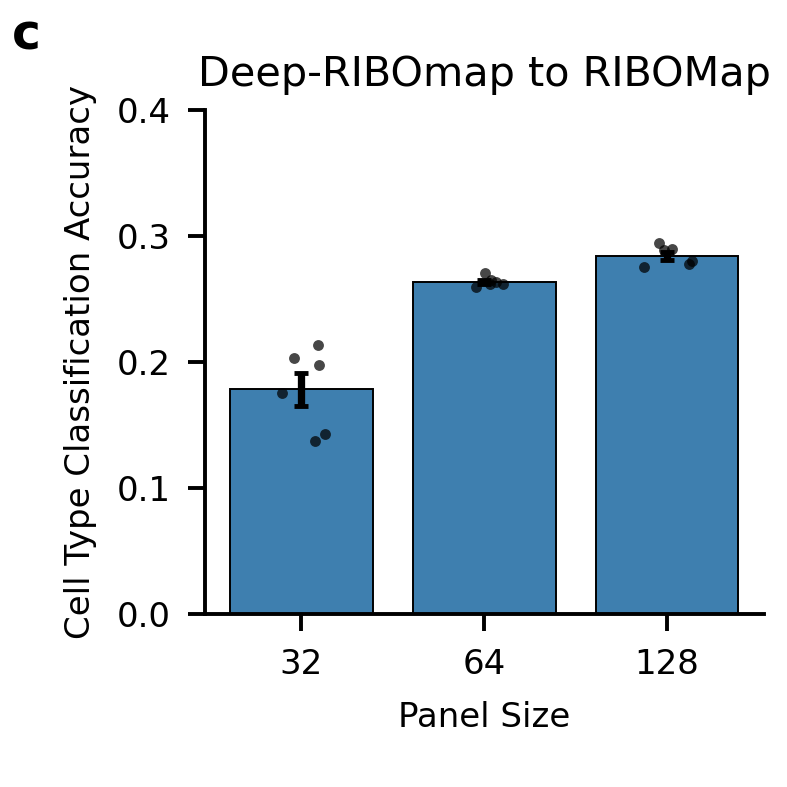

### Figure 4d - Deep-RIBOmap region transfer

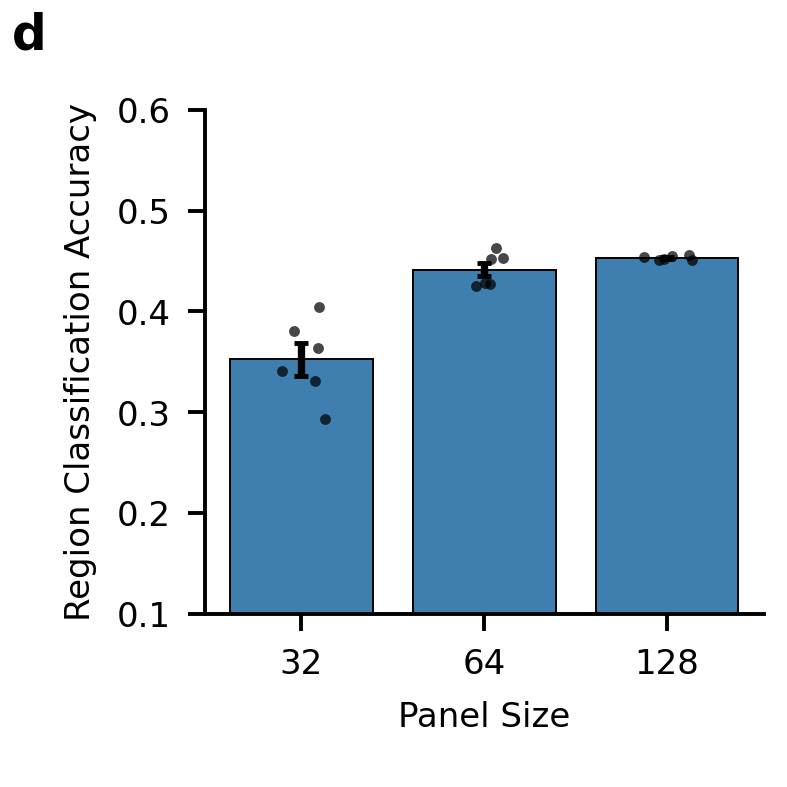

### Figure 4e - STARmap cell-type transfer

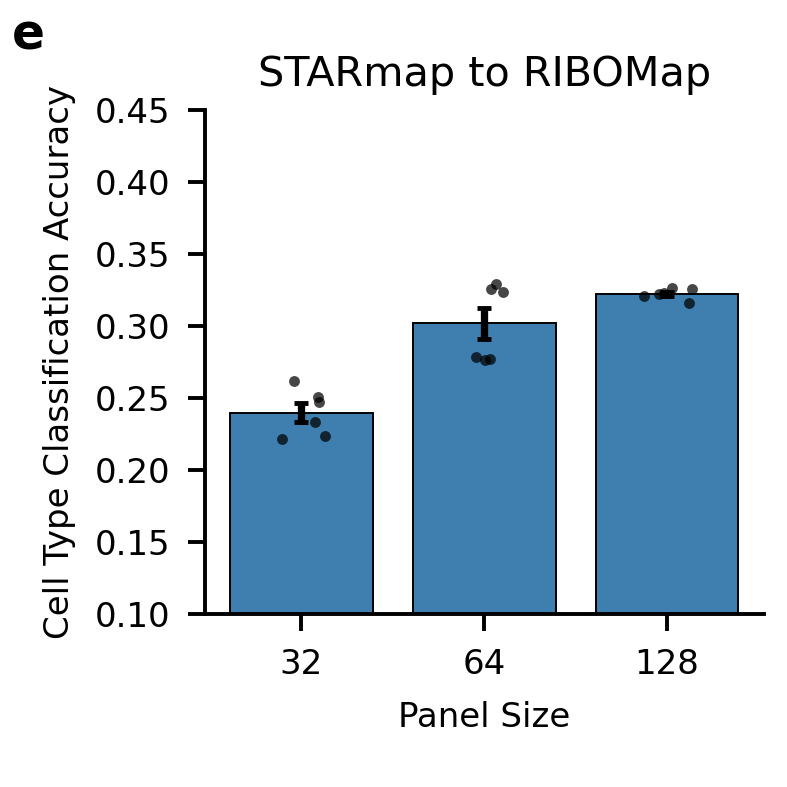

### Figure 4f - STARmap region transfer

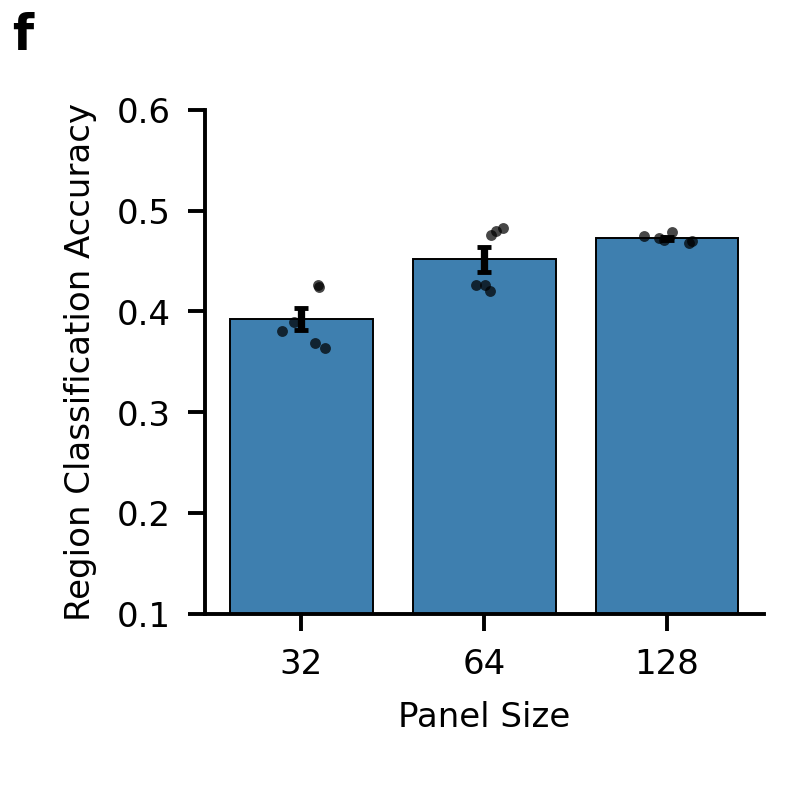

### Figure 4g - same- versus cross-modality overlap

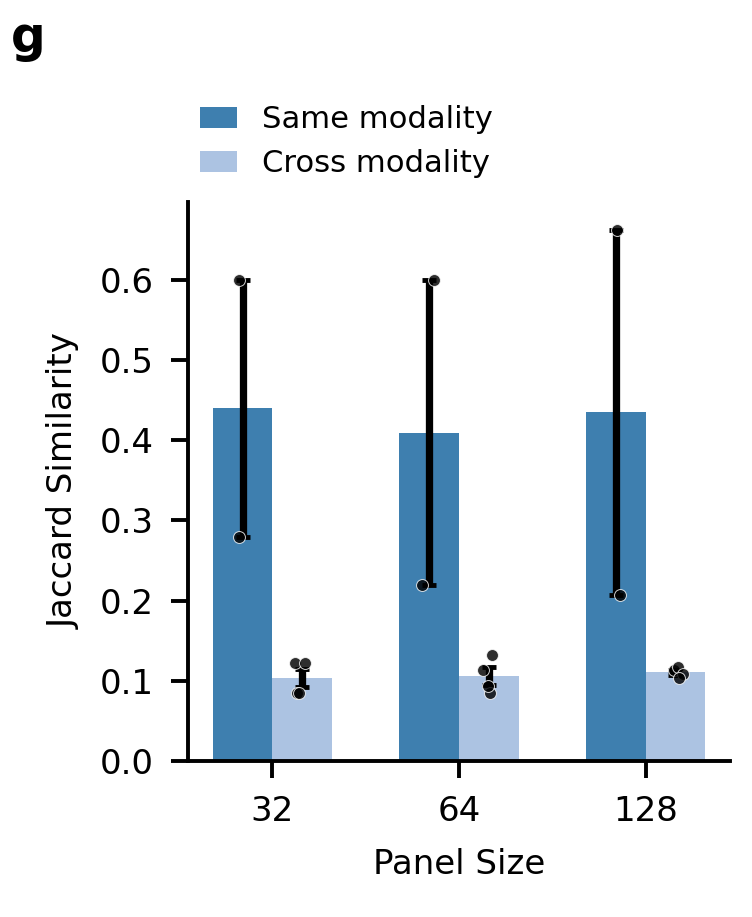

### Figure 4h - RIBOMap expression bias

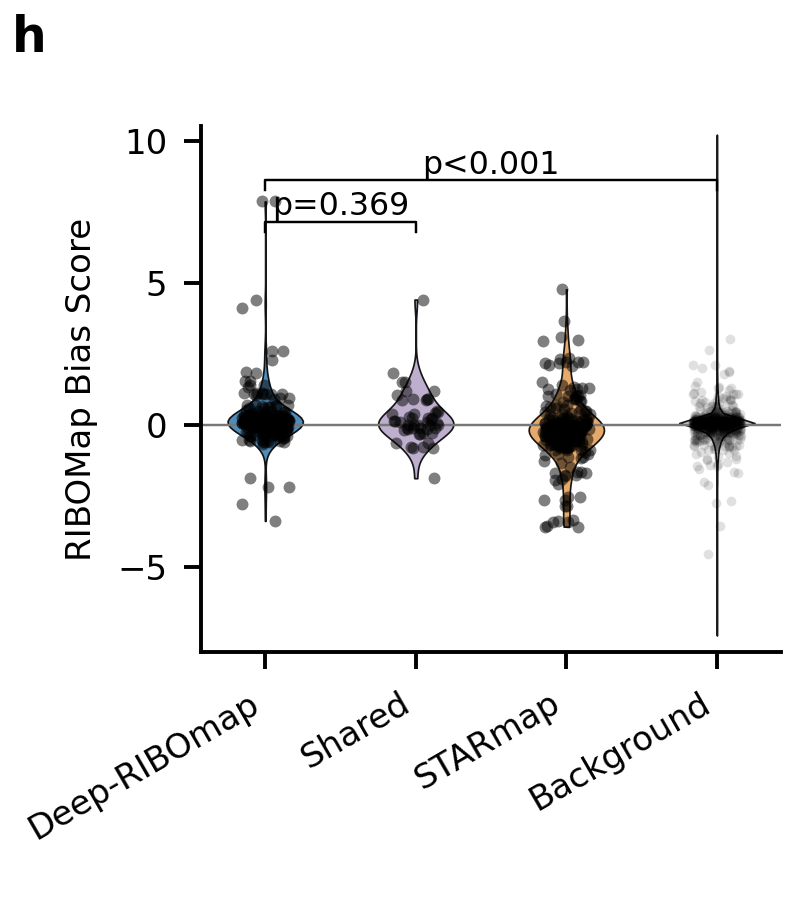

### Shared method legend

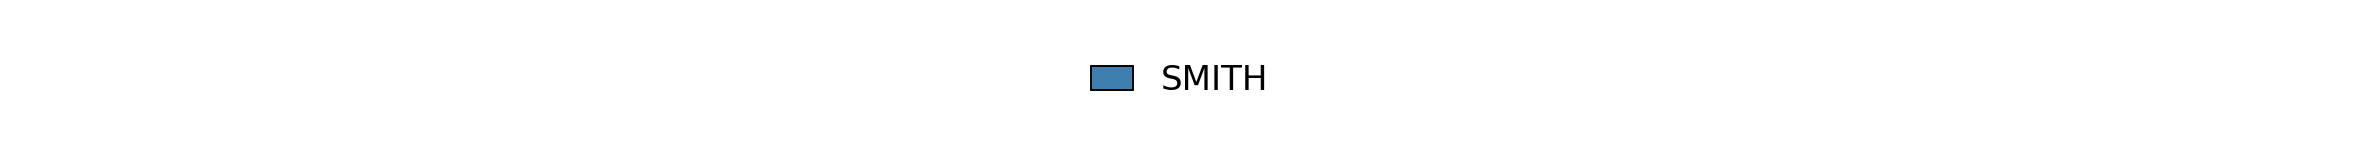

Each panel is also exported independently as editable PDF/SVG and 600-dpi TIFF under /workspace/fanyimin/SMITH_package/outputs/figure_tutorials_v3/ribomap/figures


In [5]:
figure_dir = CASE_OUTPUT / "figures"
plot_command = [sys.executable, str(ROOT / 'reproducibility/workflows/ribomap_transfer/plot_figure4.py'), '--metrics', str(CASE_OUTPUT / 'figure_data/figure4_c_f_values.tsv'), '--overlap', str(CASE_OUTPUT / 'figure_data/figure4_g_jaccard.tsv'), '--bias', str(CASE_OUTPUT / 'figure_data/figure4_h_ribomap_bias.tsv'), "--output-dir", str(figure_dir)]
subprocess.run(plot_command, cwd=ROOT, check=True)
for heading, relative, width in [('Figure 4c - Deep-RIBOmap cell-type transfer', 'figures/figure4_c.png', 430), ('Figure 4d - Deep-RIBOmap region transfer', 'figures/figure4_d.png', 430), ('Figure 4e - STARmap cell-type transfer', 'figures/figure4_e.png', 430), ('Figure 4f - STARmap region transfer', 'figures/figure4_f.png', 430), ('Figure 4g - same- versus cross-modality overlap', 'figures/figure4_g.png', 430), ('Figure 4h - RIBOMap expression bias', 'figures/figure4_h.png', 430), ('Shared method legend', 'figures/figure4_method_legend.png', 900)]:
    display(Markdown(f"### {heading}"))
    display(Image(filename=str(CASE_OUTPUT / relative), width=width))
print("Each panel is also exported independently as editable PDF/SVG and 600-dpi TIFF under", figure_dir)


## Full manuscript command

Append the following paper-scale arguments to the workflow command:

```text
--methods SMITH,PERSIST-class,PERSIST,ActiveSVM,scGIST,scGeneFit,Spapros --baseline-root external/SMITH_baselines/GPS_tools-main/baselines --baseline-python PERSIST=/opt/envs/persist/bin/python --baseline-python PERSIST-class=/opt/envs/persist/bin/python --baseline-python scGIST=/opt/envs/scgist/bin/python --panel-sizes 32,64,128 --training-seeds 1,2,3,4,5 --evaluation-seeds 1,2,3,4,5 --epochs 200
```

The workflow reproduces the quantitative logic and layout of Figure 4c-h from newly selected Deep-RIBOmap and STARmap panels. Figure 4i is deliberately omitted unless a versioned Reactome/GO snapshot is supplied. Figure 4j-n additionally require the manuscript clean-fusion aligned H5AD and are not replaced with unrelated summaries.